# TWII Next-Day Return Forecasting — Pipeline

A single **LightGBM** regressor predicting the **next-day log return** of the Taiwan
Weighted Index (`^TWII`) from causal technical indicators. The deliverable is
*predictive power measured against naive baselines*, reported **per next-day
prediction** — never a compounded price level.

> **Honest scope.** Out-of-sample R² on daily returns is expected ≈ 0 or negative;
> 51–54% directional accuracy is a *good* result. Every metric sits next to a baseline.

This notebook is deliberately thin: all logic lives in `src/twii_forecast/`; here we
just call `pipeline.run(...)` and render.

In [1]:
import sys, pathlib
# make src/ importable regardless of where the kernel is launched
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / "src" / "twii_forecast").exists():
        sys.path.insert(0, str(_p / "src")); break

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s | %(message)s", stream=sys.stdout)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

import pandas as pd
from IPython.display import Image, display

from twii_forecast import pipeline, plots, explain, evaluate, config

## 1–8. Run the end-to-end pipeline
Data → features/target → temporal-consistency selection (train only) → chronological 85/5/10 split → RobustScaler (fit on train) → LightGBM random-search + early stopping → per-next-day evaluation → SHAP.

In [2]:
r = pipeline.run(n_iter=config.N_RANDOM_SEARCH, tune=True)
print("\nsplit:", r["split"].describe())
print("volume gate passed:", r["volume_ok"])
print("features kept by temporal consistency:", len(r["kept_features"]), "/", len(r["feature_cols"]))
print("train-vs-test drift report:", r["drift_report"])

INFO twii_forecast.data | loaded cached raw data: 5241 rows


INFO twii_forecast.data | volume gate: zero=0.002 nan=0.000 degenerate=0.002 threshold=0.050


INFO twii_forecast.dataset | dataset: 5241 rows -> 5181 after dropping warmup/tail NaNs (36 features)


INFO twii_forecast.split | split: train 2005-04-06..2023-03-20 (n=4403) | val 2023-03-21..2024-04-15 (n=259) | test 2024-04-16..2026-06-04 (n=519)


INFO twii_forecast.feature_selection | temporal consistency: 72 trimonthly blocks, 2556 block pairs, 36 features


...

random search: 100%|██████████| 40/40 [00:06<00:00,  5.79it/s]

INFO twii_forecast.model | best val MAE=5.727856e-03 with params={'num_leaves': 78, 'learning_rate': 0.04282187151170881, 'max_depth': 10, 'min_child_samples': 97, 'feature_fraction': 0.6361207809225795, 'bagging_fraction': 0.5481954810767496, 'lambda_l1': 3.2584569136159827, 'lambda_l2': 0.019005594069851025}


INFO twii_forecast.model | refit best_iteration=40


INFO twii_forecast.model | saved model -> /Users/wanchuan/quant-demo/data/processed/lgbm_model.txt, params -> /Users/wanchuan/quant-demo/data/processed/best_params.json



split: train 2005-04-06..2023-03-20 (n=4403) | val 2023-03-21..2024-04-15 (n=259) | test 2024-04-16..2026-06-04 (n=519)
volume gate passed: True
features kept by temporal consistency: 23 / 36
train-vs-test drift report: /Users/wanchuan/quant-demo/reports/drift_report.html


## Temporal consistency analysis
AUC ≈ 0.5 ⇒ the feature looks the same across 3-month periods (stable, **kept**); AUC → 1 ⇒ drift (**dropped**). Fit on the training period only.

In [3]:
auc = r["auc_table"]
display(auc.style.format({"agg_auc": "{:.3f}"}).hide(axis="index"))
print("dropped (drift):", auc.loc[~auc.keep, "feature"].tolist())

feature,agg_auc,keep
delta_v,0.519,True
delta_v_ma_5,0.540,True
difference,0.542,True
sign_delta_open,0.542,True
c_minus_o,0.543,True
daily_return,0.544,True
ret_lag_0,0.544,True
delta_c,0.545,True
ret_lag_1,0.545,True
ret_lag_5,0.545,True


dropped (drift): ['amplitude', 'macd', 'h_minus_l', 'bb_low', 'ma_5', 'ema_5', 'ma_10', 'ema_10', 'ma_20', 'bb_high', 'ema_20', 'ma_60', 'ema_60']


## 6. Evaluation — per next-day prediction, vs. baselines

The headline is **directional accuracy**. Baselines: *persistence* (r̂ = 0) and
*historical mean* (r̂ = mean train return). The historical-mean baseline is the
meaningful directional yardstick (persistence has sign 0, so its DirAcc is 0 by
construction).

In [4]:
print(evaluate.format_table(r["metrics_table"]))

                            mae          rmse  dir_acc       ic       r2
model              1.087595e-02  1.558634e-02  +0.5703  +0.0519  +0.0010
persistence (r=0)  1.099182e-02  1.567383e-02  +0.0000     +nan  -0.0102
historical_mean    1.096431e-02  1.565367e-02  +0.5684  +0.0000  -0.0076


In [5]:
m = r["metrics_table"].loc["model"]; b = r["metrics_table"].loc["historical_mean"]
print(f"Model MAE {m.mae:.3e} vs persistence {r['metrics_table'].loc['persistence (r=0)','mae']:.3e}")
print(f"Model DirAcc {m.dir_acc:+.4f} vs always-up (historical mean) {b.dir_acc:+.4f}")
print(f"IC {m.ic:+.4f}  |  out-of-sample R² {m.r2:+.4f}  (≈0 or negative is expected & honest)")

Model MAE 1.088e-02 vs persistence 1.099e-02
Model DirAcc +0.5703 vs always-up (historical mean) +0.5684
IC +0.0519  |  out-of-sample R² +0.0010  (≈0 or negative is expected & honest)


## 7. SHAP feature importance (TreeSHAP)
Global importance over the test matrix. The paper found `difference` / `c_minus_o` (both from Cₜ−Oₜ) dominated — we check whether that holds for next-day *return* prediction here.

,feature,mean_abs_shap
0,delta_v_ma_5,0.000253
1,intraday_ma_10,0.000248
2,delta_c_ma_20,0.000156
3,ret_lag_3,0.000134
4,delta_v,0.000123
5,ret_lag_5,0.000121
6,delta_c,0.000117
7,delta_v_ma_10,0.000115
8,delta_c_ma_5,0.000106
9,intraday_ma_5,0.000098


INFO twii_forecast.explain | saved SHAP plots: {'beeswarm': '/Users/wanchuan/quant-demo/reports/shap_beeswarm.png', 'bar': '/Users/wanchuan/quant-demo/reports/shap_bar.png'}


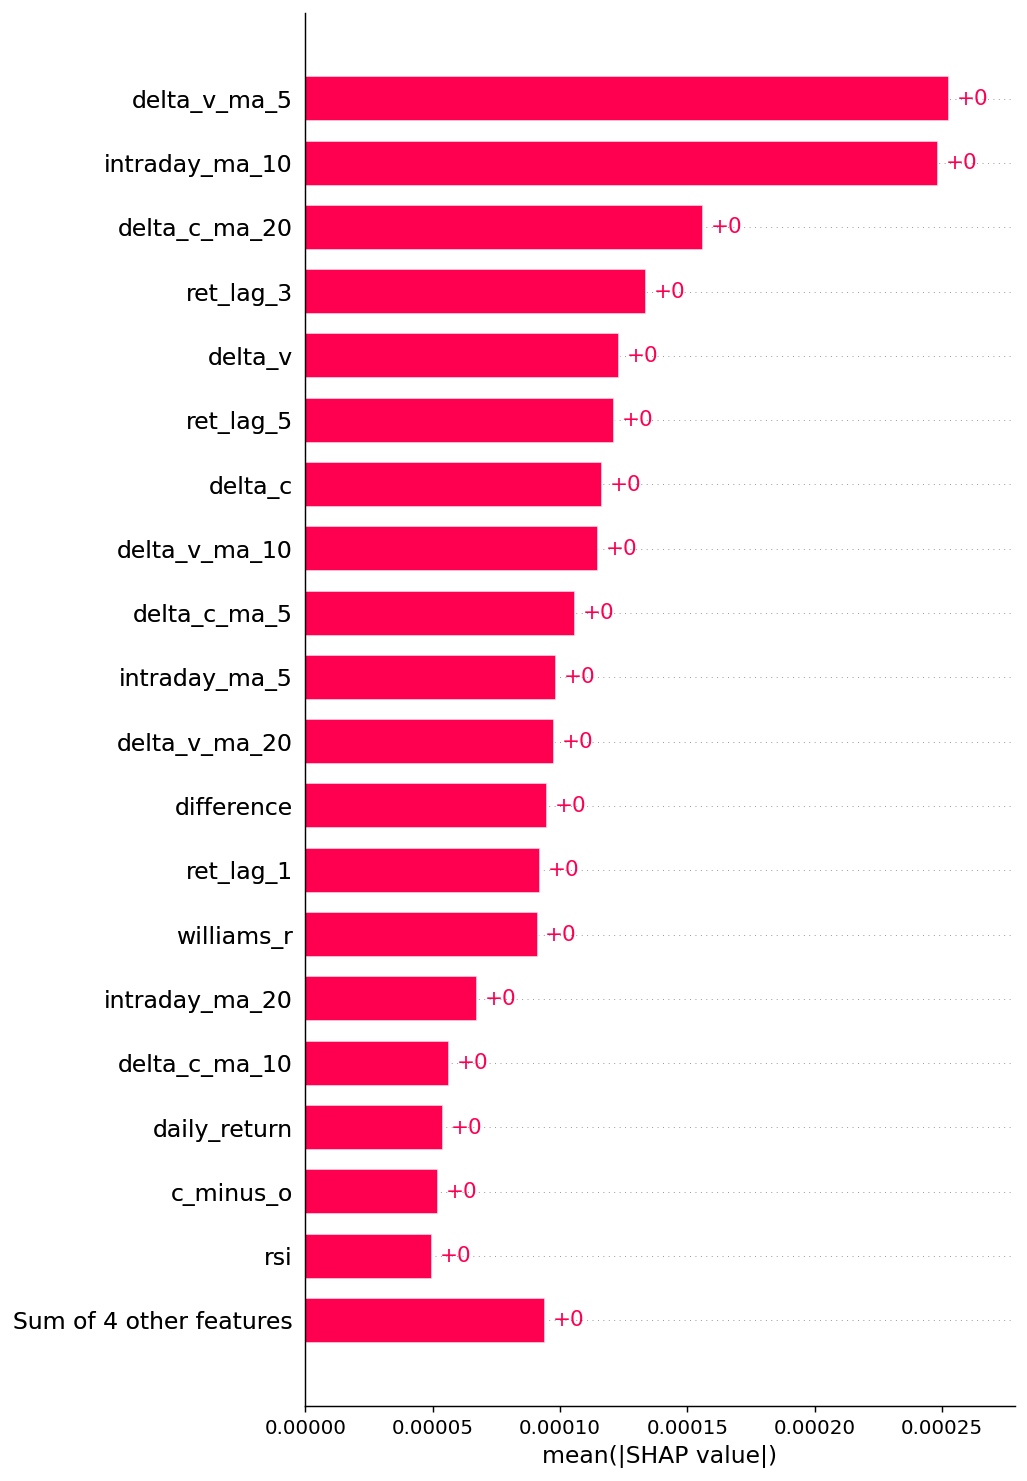

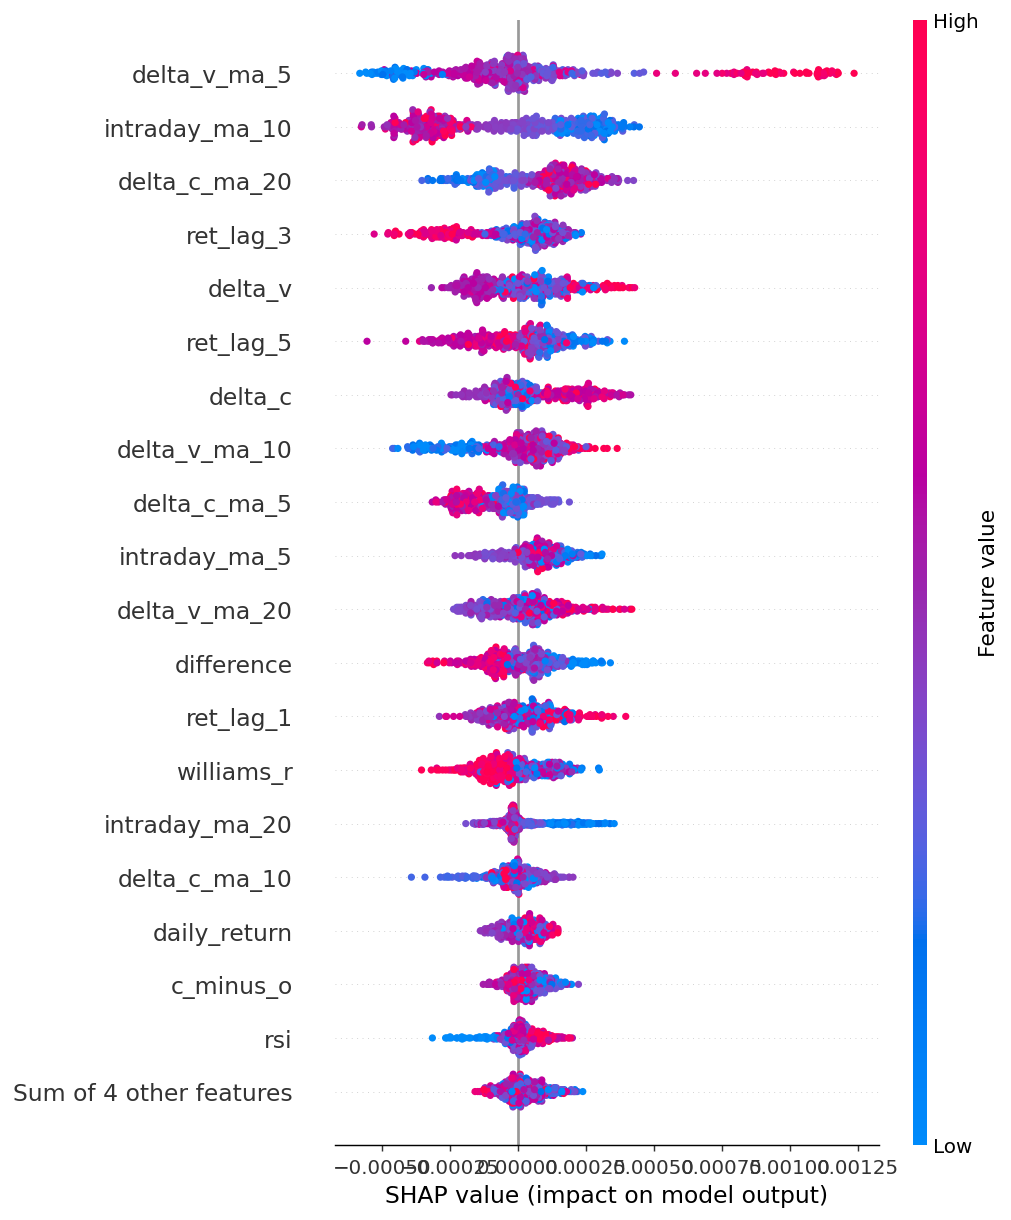

In [6]:
display(r["importance"].head(15))
paths = explain.save_plots(r["shap_values"])
display(Image(paths["bar"])); display(Image(paths["beeswarm"]))

## 12. Diagnostic plots
Candles of the test window, the per-prediction scatter (IC annotated), the residual histogram, and a **sanity-only** compounded path (explicitly excluded from the reported metrics).

INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/test_candles.png


INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/pred_vs_actual.png


INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/residuals.png


INFO twii_forecast.plots | saved /Users/wanchuan/quant-demo/reports/compounded_sanity.png


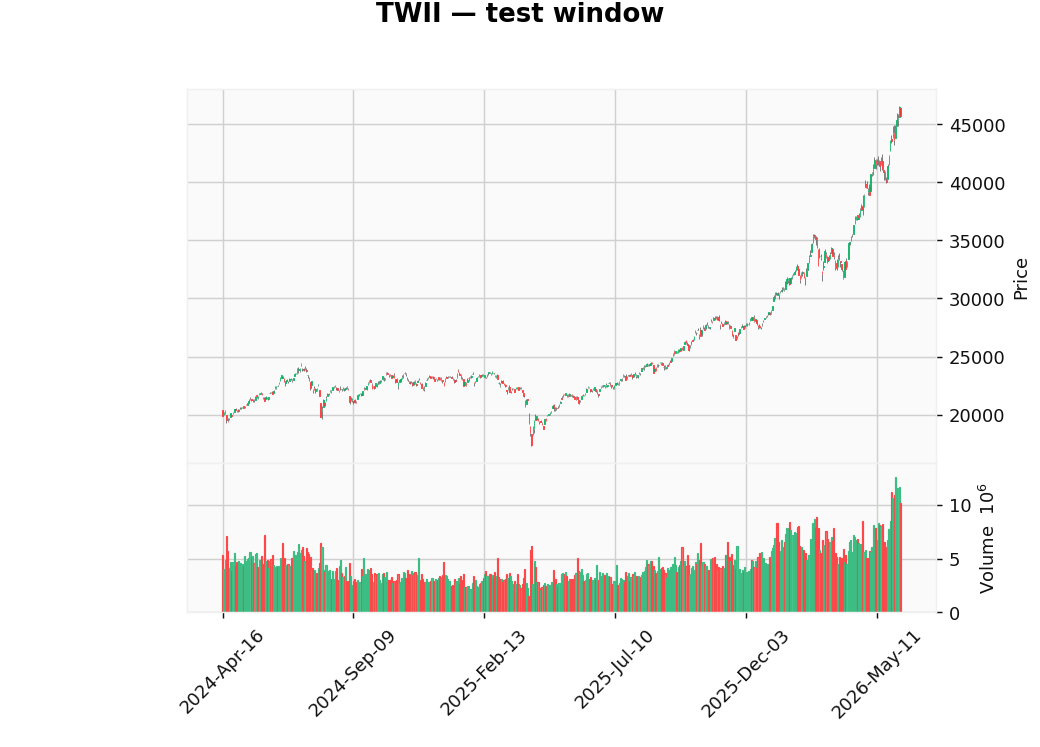

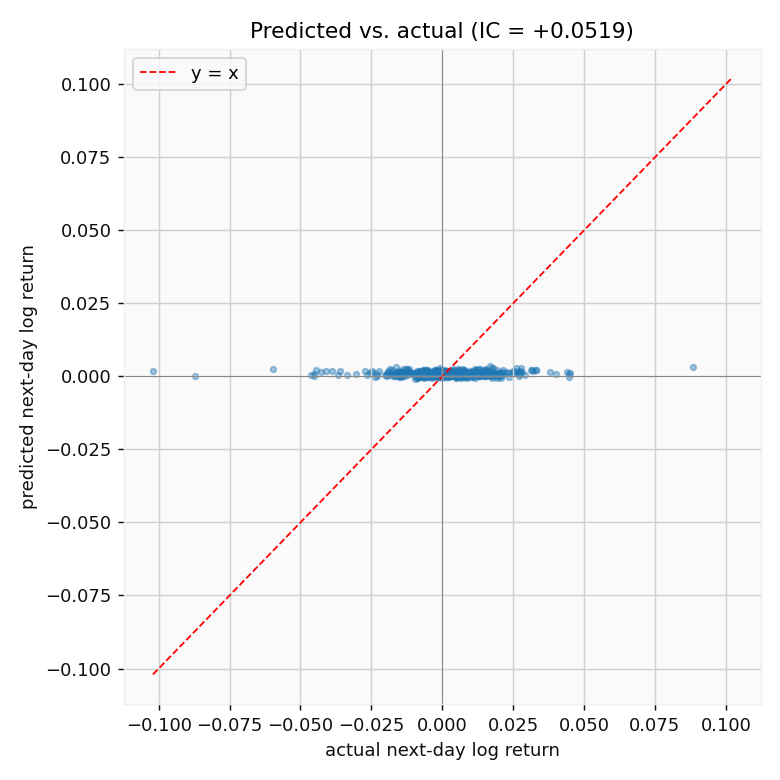

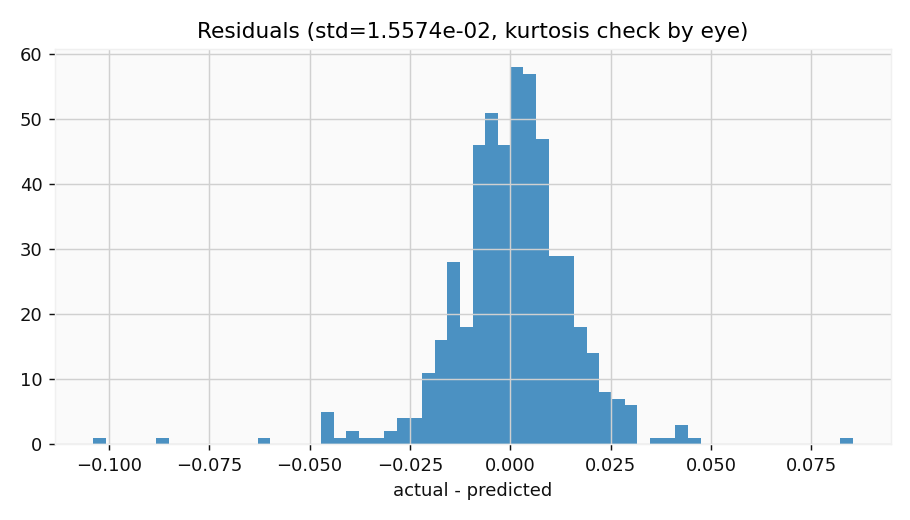

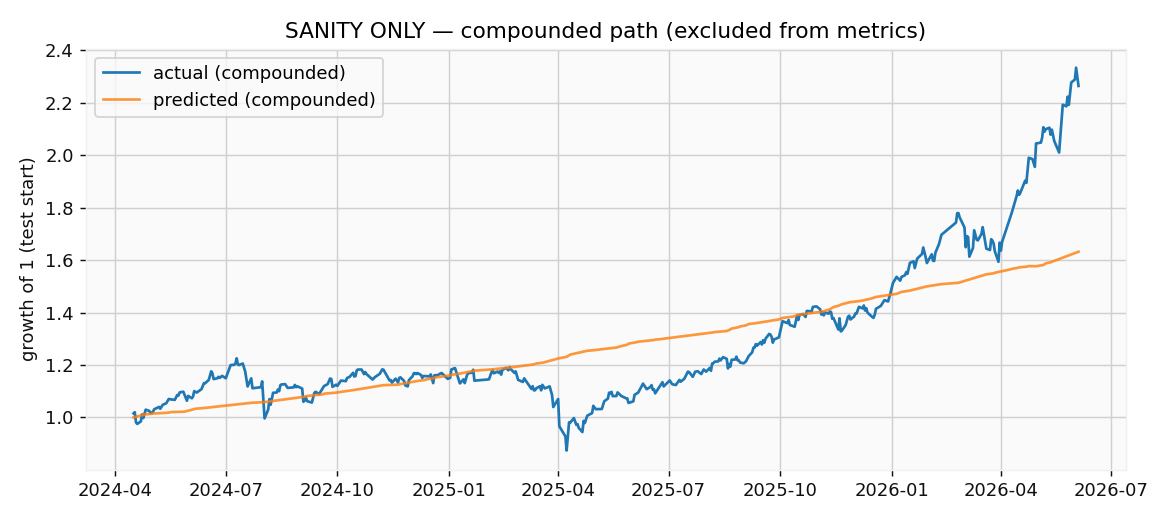

In [7]:
sp = r["split"]
cands = plots.candles(r["df_ohlcv"].loc[sp.test.index])
ic = r["metrics_table"].loc["model", "ic"]
pva = plots.pred_vs_actual(r["y_test"].values, r["y_pred"].values, ic)
res = plots.residual_hist(r["y_test"].values, r["y_pred"].values)
comp = plots.compounded_sanity(r["y_test"].index, r["y_test"].values, r["y_pred"].values)
for p in (cands, pva, res, comp):
    display(Image(p))

## Takeaway

On a single modern test split, the tuned LightGBM **marginally** beats the persistence
baseline on MAE/RMSE and edges the always-up baseline on directional accuracy, with an
IC of a few percent and R² ≈ 0. That is exactly the honest, un-inflated result the plan
predicted — predictive *signal* that is real but small, reported per next-day prediction
and always next to its baseline. Temporal-consistency selection correctly discarded the
non-stationary price-level features (MAs, EMAs, Bollinger bands, MACD), keeping the
stationary return/difference/oscillator family that SHAP then ranks at the top.